In [1]:
import tensorflow as tf


train_data = tf.keras.preprocessing.image_dataset_from_directory(
    "gesture_dataset",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    "gesture_dataset",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32
)
class_names = train_data.class_names



I0000 00:00:1775053609.051765    5028 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775053609.268745    5028 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775053610.466736    5028 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Found 12706 files belonging to 8 classes.
Using 10165 files for training.


I0000 00:00:1775053614.112435    5028 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2143 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 12706 files belonging to 8 classes.
Using 2541 files for validation.


In [2]:
normalization_layer = tf.keras.layers.Rescaling(1.0/255.0)

train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
val_data = val_data.map(lambda x, y: (normalization_layer(x), y))

In [13]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
])

In [14]:
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout,LSTM
from tensorflow.keras import Sequential


In [15]:
model = Sequential([
    data_augmentation,
    Conv2D(32,kernel_size=(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64,kernel_size=(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(128,kernel_size=(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    
    Dense(128,activation='relu'),
    Dropout(0.4),
    Dense(len(class_names),activation='softmax')
])

In [16]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [17]:
model.fit(train_data,validation_data=val_data,epochs=20,verbose=1,batch_size=32)

Epoch 1/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 23s 70ms/step - accuracy: 0.1975 - loss: 2.0352 - val_accuracy: 0.2393 - val_loss: 1.9406
Epoch 2/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.3700 - loss: 1.6617 - val_accuracy: 0.5651 - val_loss: 1.1843
Epoch 3/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.5337 - loss: 1.2145 - val_accuracy: 0.6667 - val_loss: 0.9014
Epoch 4/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.6461 - loss: 0.9207 - val_accuracy: 0.7702 - val_loss: 0.6102
Epoch 5/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.6863 - loss: 0.8242 - val_accuracy: 0.7977 - val_loss: 0.5477
Epoch 6/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.7480 - loss: 0.6559 - val_accuracy: 0.8682 - val_loss: 0.3894
Epoch 7/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.7829 - loss: 0.5669 - val_accuracy: 0.8800 - val_loss: 0.3379
Epoch 8/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.7710 - loss: 0.6124 - 

In [18]:
model.save('gesture.h5')

In [20]:
y_true = []
y_pred = []

for images, labels in val_data:
    preds = model.predict(images)
    preds = preds.argmax(axis=1)

    y_pred.extend(preds)
    y_true.extend(labels.numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━

In [21]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_true, y_pred)
print("Accuracy:", acc)

Accuracy: 0.9689098780007871


In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[296   5   3   0   0   0   0   0]
 [  3 321   6   0   0   0   1   0]
 [  1   2 296   8   3   0   0   0]
 [  0   0   2 287  13   0   0   0]
 [  0   0   1   3 312   7   0   0]
 [  0   0   0   0  17 297   0   0]
 [  0   1   0   0   0   0 328   1]
 [  0   2   0   0   0   0   0 325]]


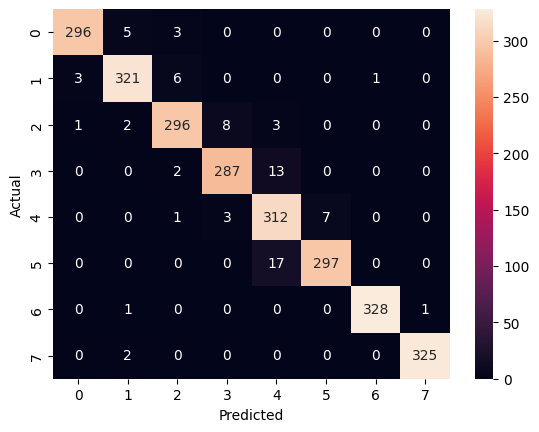

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [26]:
from sklearn.metrics import f1_score

f1 = f1_score(y_true, y_pred, average='weighted')
print("F1 Score:", f1)

F1 Score: 0.9690505037037113
